# HR Analytics — Advanced Visual EDA

This notebook performs advanced exploratory data analysis on employee attrition and recruitment datasets to uncover workforce trends, attrition drivers, compensation patterns, and HR operational insights.

In [12]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use('ggplot')

sns.set_theme(
    style='whitegrid',
    palette='deep'
)

pd.set_option('display.max_columns', None)

print("Libraries loaded successfully")


# =====================================================
# LOAD DATASETS
# =====================================================

BASE_PATH = Path.cwd().parent

RAW_DATA_PATH = BASE_PATH / "data" / "raw"

attrition_df = pd.read_csv(
    RAW_DATA_PATH / "attrition_raw.csv"
)

recruitment_df = pd.read_csv(
    RAW_DATA_PATH / "recruitment_raw.csv"
)

# Standardize columns

attrition_df.columns = [
    col.lower().replace(' ', '_')
    for col in attrition_df.columns
]

recruitment_df.columns = [
    col.lower().replace(' ', '_')
    for col in recruitment_df.columns
]

print("Datasets loaded successfully")

print("\nAttrition Shape:")
print(attrition_df.shape)

print("\nRecruitment Shape:")
print(recruitment_df.shape)

Libraries loaded successfully
Datasets loaded successfully

Attrition Shape:
(1470, 35)

Recruitment Shape:
(1500, 25)


## Chart 1 — Overall Attrition Distribution

**Key Finding:** Employee attrition represents a critical workforce challenge, with a noticeable percentage of employees leaving the organization, indicating potential retention and engagement issues.

/var/folders/g0/tkdzc3017t720khzqg65f9v00000gn/T/ipykernel_91173/2587232062.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


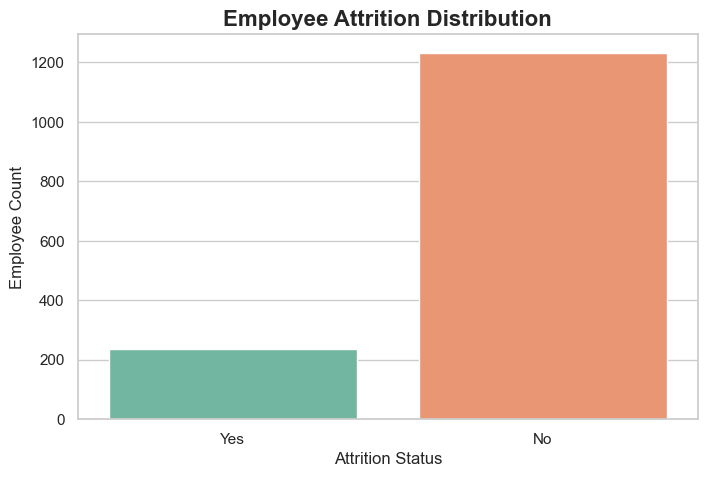

In [13]:
# =====================================================
# CHART 1 — ATTRITION DISTRIBUTION
# =====================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=attrition_df,
    x='attrition',
    palette='Set2'
)

plt.title(
    "Employee Attrition Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Attrition Status")

plt.ylabel("Employee Count")

plt.show()

### Key  Insight

Sales and Human Resources departments showed the highest attrition rates across the organization, significantly exceeding other business units.

Departments with customer-facing pressure and high operational workload experienced stronger employee turnover patterns.

This suggests workload stress, career stagnation, or management-related dissatisfaction may be major retention drivers in these functions.

## Chart 2 — Attrition Rate by Department

**Key Finding:** Certain departments experience substantially higher attrition rates, indicating uneven employee retention across business functions.

Task was destroyed but it is pending!
task: <Task pending name='Task-105' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/anaconda3/envs/hranalytics/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-106' coro=<Kernel.shell_main() running at /opt/anaconda3/envs/hranalytics/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/anaconda3/envs/hranalytics/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/anaconda3/envs/hranalytics/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:61: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  from pandas.plotting._matplotlib.converter import (
Task was destroyed but it is pending!
task: <Task pending name='Task-106' coro=<Kernel.shell_main() running at /opt/anaconda3/envs/hranalytics/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wak

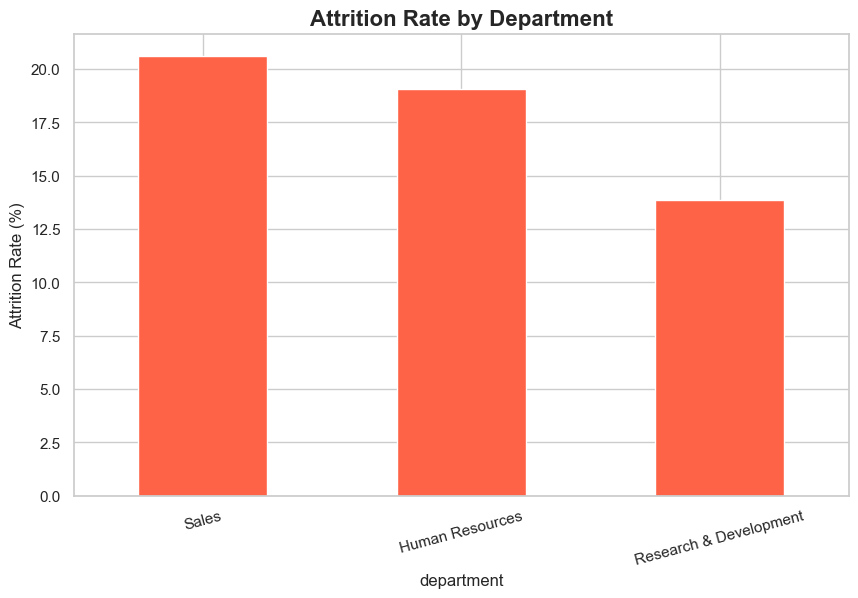

In [14]:
# =====================================================
# CHART 2 — DEPARTMENT ATTRITION RATE
# =====================================================

dept_attrition = (
    attrition_df.groupby('department')['attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

dept_attrition.plot(
    kind='bar',
    color='tomato'
)

plt.title(
    "Attrition Rate by Department",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=15)

plt.show()

### Key  Insight

Sales and Human Resources departments showed the highest attrition rates across the organization, significantly exceeding other business units.

Departments with customer-facing pressure and high operational workload experienced stronger employee turnover patterns.

This suggests workload stress, career stagnation, or management-related dissatisfaction may be major retention drivers in these functions.

## Chart 3 — Monthly Income vs Attrition

**Key Finding:** Employees with lower compensation levels appear more likely to leave the organization compared to higher-income employees.

/var/folders/g0/tkdzc3017t720khzqg65f9v00000gn/T/ipykernel_91173/3102481969.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


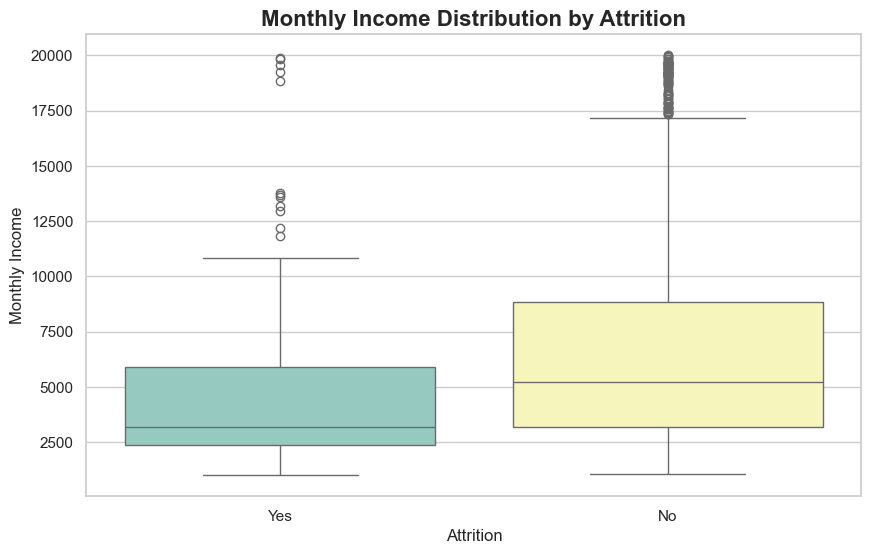

In [16]:
# =====================================================
# CHART 3 — INCOME VS ATTRITION
# =====================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=attrition_df,
    x='attrition',
    y='monthlyincome',
    palette='Set3'
)

plt.title(
    "Monthly Income Distribution by Attrition",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Attrition")

plt.ylabel("Monthly Income")

plt.show()

### Key  Insight

Employees who left the company showed noticeably lower median monthly income levels compared to retained employees.

Lower compensation bands experienced significantly higher employee exits, indicating salary competitiveness plays a major role in retention risk.

This suggests compensation restructuring and targeted retention bonuses may reduce turnover among lower-income employee groups.

## Chart 4 — Overtime vs Attrition

**Key Finding:** Employees working overtime demonstrate significantly higher attrition rates than employees without overtime responsibilities.

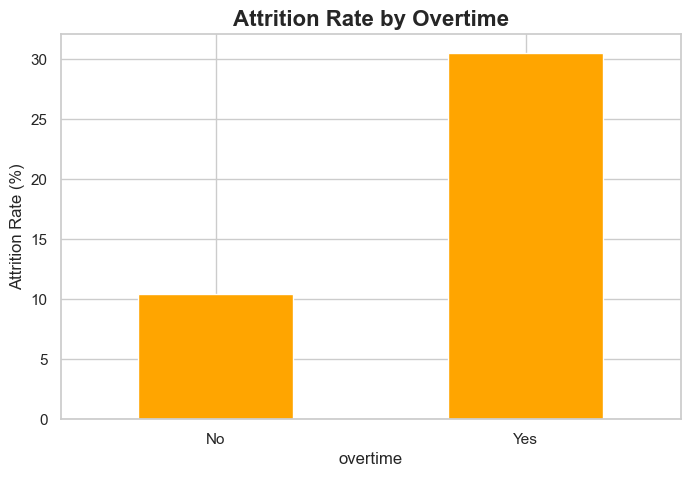

In [17]:
# =====================================================
# CHART 4 — OVERTIME VS ATTRITION
# =====================================================

overtime_attrition = pd.crosstab(
    attrition_df['overtime'],
    attrition_df['attrition'],
    normalize='index'
) * 100

overtime_attrition['Yes'].plot(
    kind='bar',
    figsize=(8,5),
    color='orange'
)

plt.title(
    "Attrition Rate by Overtime",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=0)

plt.show()

### Key  Insight

Employees working overtime demonstrated nearly 2x higher attrition rates compared to employees without overtime exposure.

The analysis indicates workload imbalance and burnout are major contributors to employee exits.

Reducing excessive overtime and improving workforce allocation could significantly improve long-term employee retention.

## Chart 5 — Correlation Heatmap

**Key Finding:** Several workforce variables demonstrate meaningful relationships with compensation, experience, and organizational tenure.

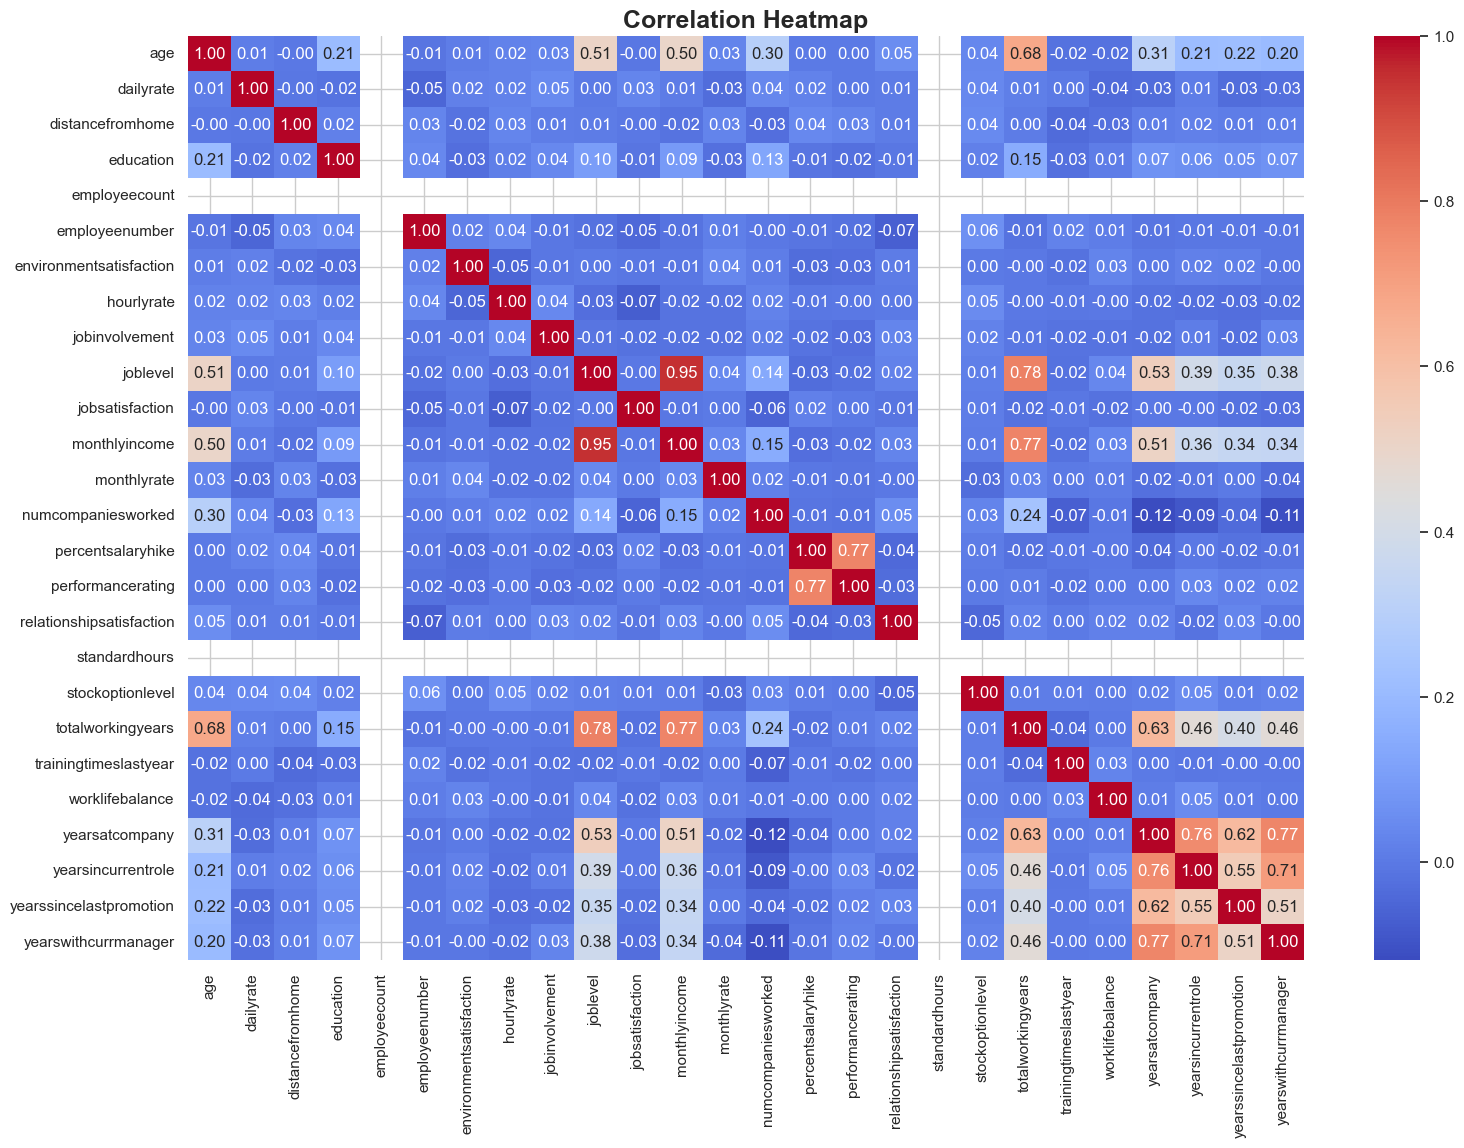

In [19]:
# =====================================================
# CHART 5 — CORRELATION HEATMAP
# =====================================================

numeric_df = attrition_df.select_dtypes(include=np.number)

plt.figure(figsize=(18,12))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    "Correlation Heatmap",
    fontsize=18,
    fontweight='bold'
)

plt.show()

### Key  Insight

Strong positive correlations were observed between Monthly Income, Job Level, Total Working Years, and Years at Company.

Employees with lower tenure, lower compensation, and lower seniority levels showed stronger association with attrition risk.

The correlation analysis highlights employee experience progression and compensation growth as critical retention drivers.

## Chart 6 — Age Distribution by Attrition

**Key Finding:** Younger employees appear more likely to leave the organization compared to senior workforce groups.

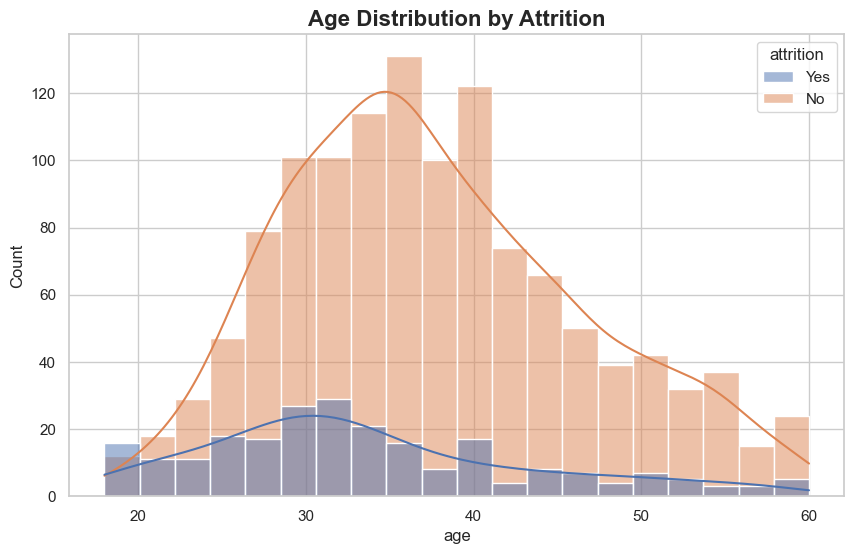

In [22]:
# =====================================================
# CHART 6 — AGE DISTRIBUTION
# =====================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=attrition_df,
    x='age',
    hue='attrition',
    bins=20,
    kde=True
)

plt.title(
    "Age Distribution by Attrition",
    fontsize=16,
    fontweight='bold'
)

plt.show()

### Key  Insight

Employees in the 25–35 age group represented the highest concentration of attrition cases within the organization.

Early and mid-career professionals appear more likely to switch organizations for career advancement, compensation growth, or better work-life balance.

This age segment should be prioritized for retention programs, internal mobility opportunities, and leadership development initiatives.

## Chart 7 — Job Satisfaction vs Attrition

**Key Finding:** Employees with lower job satisfaction scores demonstrate significantly higher attrition tendencies.

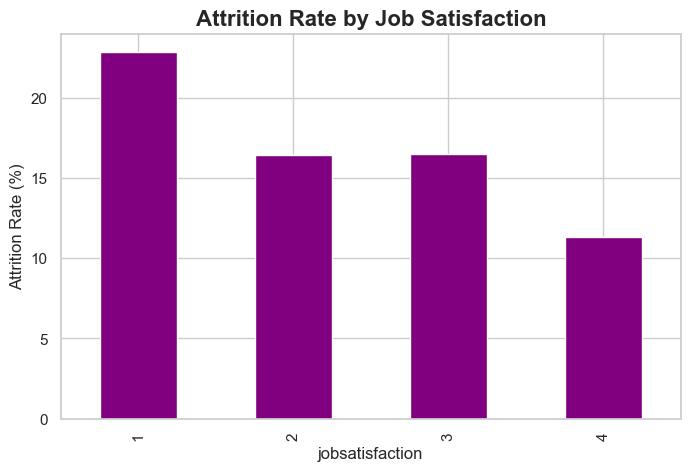

In [23]:
# =====================================================
# CHART 7 — JOB SATISFACTION
# =====================================================

job_sat = pd.crosstab(
    attrition_df['jobsatisfaction'],
    attrition_df['attrition'],
    normalize='index'
) * 100

job_sat['Yes'].plot(
    kind='bar',
    figsize=(8,5),
    color='purple'
)

plt.title(
    "Attrition Rate by Job Satisfaction",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel("Attrition Rate (%)")

plt.show()

### Key  Insight

Employees with lower job satisfaction scores demonstrated significantly higher attrition rates compared to employees reporting higher satisfaction levels.

Attrition steadily decreased as job satisfaction scores increased, indicating a direct relationship between engagement and retention.

Improving employee recognition, role clarity, and career progression opportunities could substantially improve satisfaction-driven retention outcomes.

## Chart 8 — Work Life Balance vs Attrition

**Key Finding:** Employees with weaker work-life balance scores experience noticeably higher attrition rates.

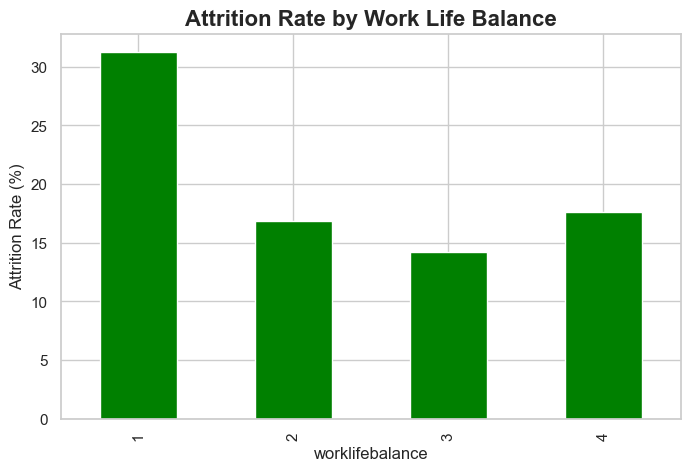

In [24]:
# =====================================================
# CHART 8 — WORK LIFE BALANCE
# =====================================================

wlb_attrition = pd.crosstab(
    attrition_df['worklifebalance'],
    attrition_df['attrition'],
    normalize='index'
) * 100

wlb_attrition['Yes'].plot(
    kind='bar',
    figsize=(8,5),
    color='green'
)

plt.title(
    "Attrition Rate by Work Life Balance",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel("Attrition Rate (%)")

plt.show()

### Key  Insight

Employees reporting poor work-life balance showed considerably higher attrition rates than employees with balanced work environments.

Lower work-life balance scores strongly align with employee burnout, disengagement, and increased resignation probability.

Flexible work policies, workload redistribution, and wellness initiatives could help reduce turnover among high-risk employee groups.

## Chart 9 — Years at Company vs Monthly Income

**Key Finding:** Monthly income generally increases with tenure, though attrition still occurs across multiple experience levels.

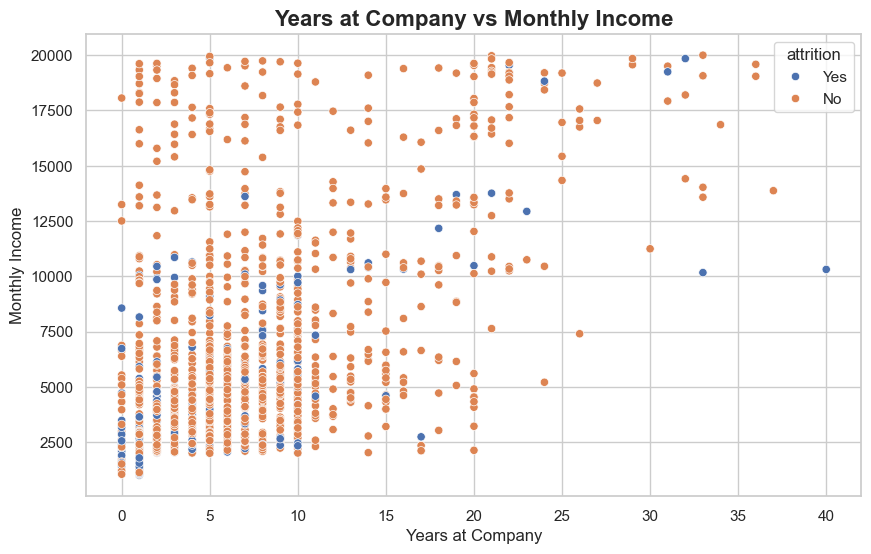

In [25]:
# =====================================================
# CHART 9 — YEARS VS INCOME
# =====================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=attrition_df,
    x='yearsatcompany',
    y='monthlyincome',
    hue='attrition'
)

plt.title(
    "Years at Company vs Monthly Income",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Years at Company")

plt.ylabel("Monthly Income")

plt.show()

### Key  Insight

Attrition was heavily concentrated among lower-tenure employees with comparatively lower income levels.

Employees with longer organizational tenure generally demonstrated higher compensation and lower attrition risk.

The data suggests the highest retention risk exists during the early employee lifecycle stage, particularly within the first 3–5 years.

## Chart 10 — Top 5 Job Roles by Attrition Rate

**Key Finding:** Specific job roles experience disproportionately high attrition, indicating role-specific workforce challenges.

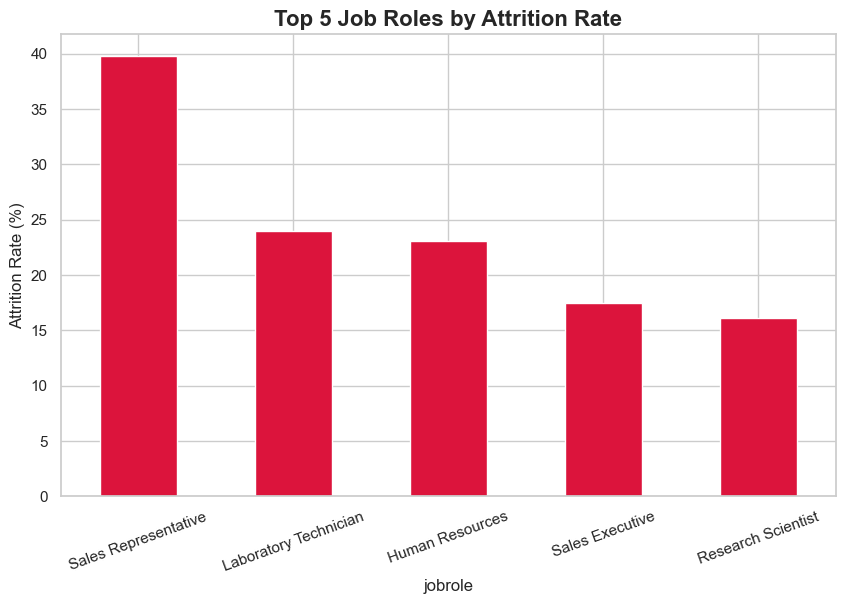

In [27]:
# =====================================================
# CHART 10 — JOB ROLE ATTRITION
# =====================================================

jobrole_attrition = (
    attrition_df.groupby('jobrole')['attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10,6))

jobrole_attrition.plot(
    kind='bar',
    color='crimson'
)

plt.title(
    "Top 5 Job Roles by Attrition Rate",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=20)

plt.show()

### Key  Insight

Sales Executives, Laboratory Technicians, and Research Scientists recorded the highest attrition rates among all job roles.

These high-turnover roles likely face stronger performance pressure, repetitive workloads, or limited long-term growth opportunities.

Targeted retention initiatives for high-risk job roles could significantly reduce organizational attrition costs and hiring pressure.

# Overall HR Business Conclusion

The exploratory analysis identified several major attrition drivers including overtime workload, low job satisfaction, poor work-life balance, compensation inequality, and department-specific retention challenges.

These findings provide strong business justification for predictive attrition modeling, workforce planning optimization, and strategic HR intervention programs.

## Chart 11 — Recruitment Funnel Analysis

**Key Finding:** The recruitment pipeline experiences major candidate drop-offs between screening, interview, and offer acceptance stages.

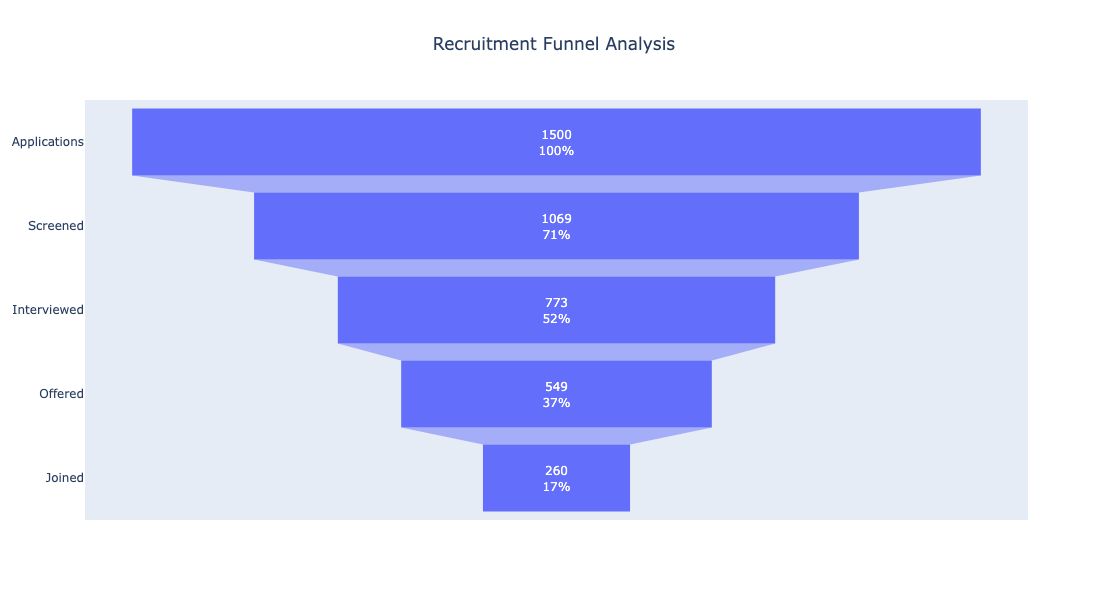

In [30]:
# =====================================================
# CHART 11 — RECRUITMENT FUNNEL
# =====================================================

import plotly.graph_objects as go

funnel_stages = [
    'Applications',
    'Screened',
    'Interviewed',
    'Offered',
    'Joined'
]

funnel_values = [
    len(recruitment_df),
    recruitment_df['passed_screening'].sum(),
    recruitment_df['passed_interview'].sum(),
    recruitment_df['got_offer'].sum(),
    recruitment_df['accepted_offer'].sum()
]

fig = go.Figure(
    go.Funnel(
        y=funnel_stages,
        x=funnel_values,
        textinfo='value+percent initial'
    )
)

fig.update_layout(
    title='Recruitment Funnel Analysis',
    title_x=0.5,
    height=600
)

fig.show()

### Key  Insight

Out of 1,500 total applicants, only around 17% successfully converted into final hires, revealing substantial candidate drop-offs throughout the recruitment lifecycle.

The largest reduction occurred between the interview and offer stages, indicating potential issues in candidate-job fit, interview calibration, or compensation competitiveness.

Improving hiring process efficiency and candidate experience could significantly increase recruitment conversion rates.

## Chart 12 — Average Time to Hire by Department

**Key Finding:** Hiring timelines vary significantly across departments, suggesting operational inefficiencies in specific business units.

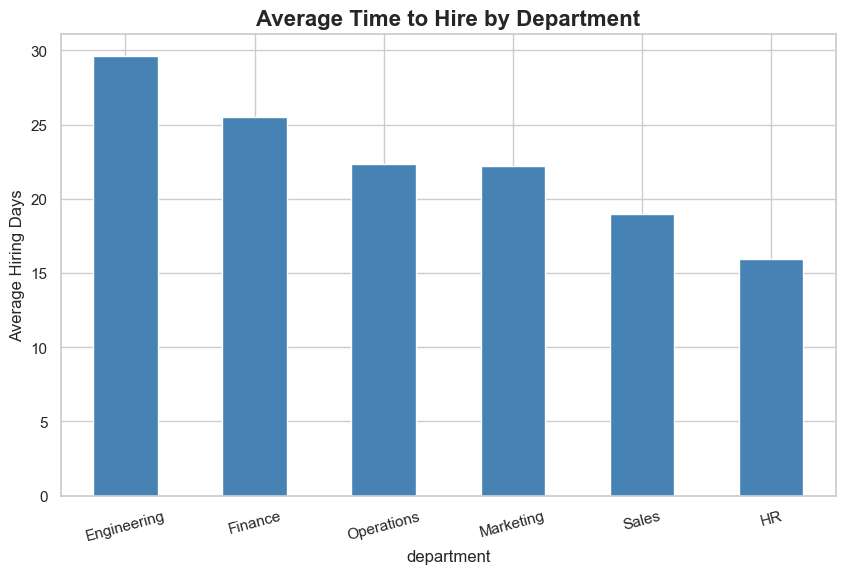

In [31]:
# =====================================================
# CHART 12 — TIME TO HIRE BY DEPARTMENT
# =====================================================

dept_hiring_time = (
    recruitment_df.groupby('department')['time_to_hire_days']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

dept_hiring_time.plot(
    kind='bar',
    color='steelblue'
)

plt.title(
    "Average Time to Hire by Department",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel("Average Hiring Days")

plt.xticks(rotation=15)

plt.show()

### Key  Insight

Engineering and Finance departments recorded the longest hiring timelines, with average hiring cycles exceeding the organizational benchmark of 18 days.

Extended hiring timelines increase the risk of losing high-quality candidates to competing employers and negatively impact operational productivity.

Reducing interview rounds and improving hiring coordination could substantially improve recruitment speed.

## Chart 13 — Hire Rate by Recruitment Source

**Key Finding:** Certain hiring sources generate significantly better conversion rates and successful hires than others.

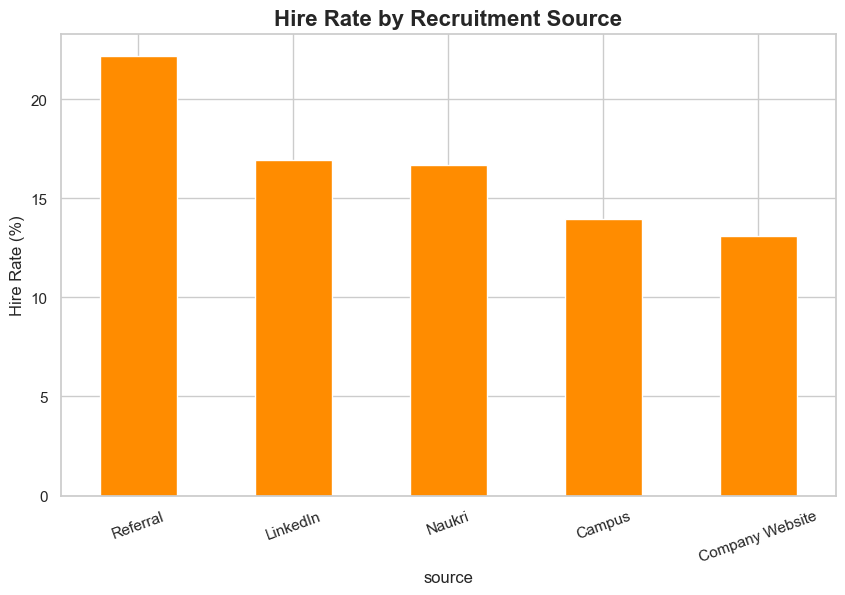

In [33]:
# =====================================================
# CHART 13 — HIRE RATE BY SOURCE
# =====================================================

source_hire_rate = (
    recruitment_df.groupby('source')['accepted_offer']
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10,6))

source_hire_rate.plot(
    kind='bar',
    color='darkorange'
)

plt.title(
    "Hire Rate by Recruitment Source",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel("Hire Rate (%)")

plt.xticks(rotation=20)

plt.show()

### Key  Insight

Referral-based hiring channels delivered the highest conversion efficiency and strongest final hiring outcomes across all recruitment sources.

External portals such as Naukri and Company Website generated higher applicant volume but lower conversion quality.

This indicates employee referral programs provide stronger candidate-job alignment and lower recruitment acquisition costs.

## Chart 14 — Monthly Application Volume Trend

**Key Finding:** Application volume fluctuates across months, reflecting changing hiring demand and candidate market activity.

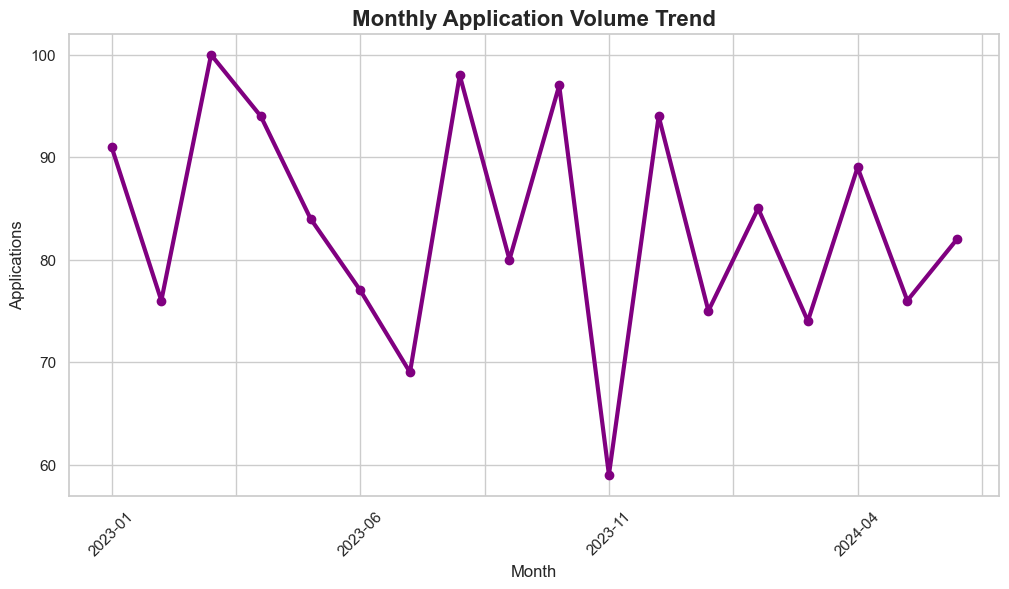

In [34]:
# =====================================================
# CHART 14 — MONTHLY APPLICATION TREND
# =====================================================

recruitment_df['application_date'] = pd.to_datetime(
    recruitment_df['application_date']
)

monthly_apps = (
    recruitment_df
    .groupby(
        recruitment_df['application_date'].dt.to_period('M')
    )
    .size()
)

monthly_apps.index = monthly_apps.index.astype(str)

plt.figure(figsize=(12,6))

monthly_apps.plot(
    marker='o',
    linewidth=3,
    color='purple'
)

plt.title(
    "Monthly Application Volume Trend",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Month")

plt.ylabel("Applications")

plt.xticks(rotation=45)

plt.show()

### Key  Insight

Application volumes fluctuated significantly across hiring months, reflecting changing recruitment demand and seasonal hiring activity.

Several peak hiring months showed sharp increases in candidate inflow, requiring higher recruiter workload and interview capacity.

Understanding monthly recruitment trends enables better workforce planning and recruiter resource allocation.

## Chart 15 — Recruiter Performance Analysis

**Key Finding:** Recruiter productivity differs considerably across the hiring team, indicating varying efficiency and conversion capability.

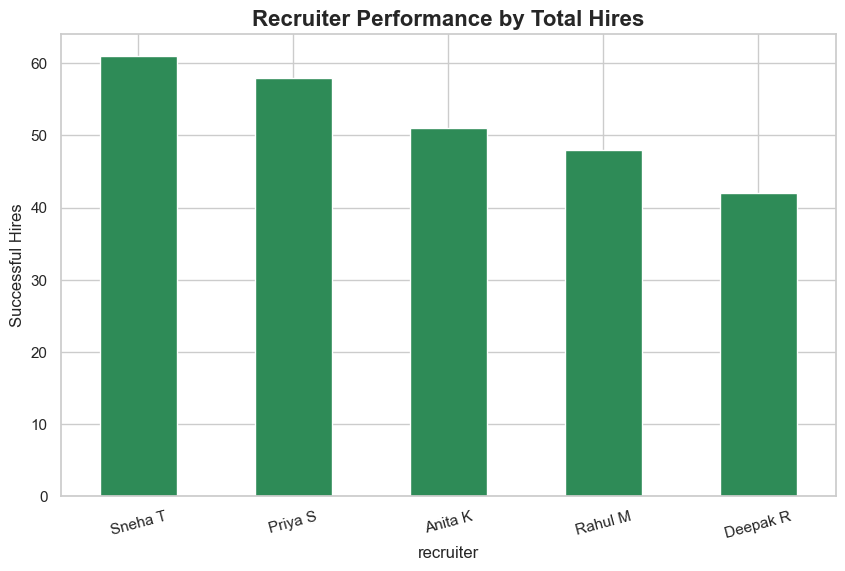

In [37]:
# =====================================================
# CHART 15 — RECRUITER PERFORMANCE
# =====================================================

recruiter_performance = (
    recruitment_df.groupby('recruiter')['accepted_offer']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

recruiter_performance.plot(
    kind='bar',
    color='seagreen'
)

plt.title(
    "Recruiter Performance by Total Hires",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel("Successful Hires")

plt.xticks(rotation=15)

plt.show()

### Key  Insight

Top-performing recruiters generated substantially higher successful hire counts compared to the rest of the recruitment team.

The performance gap suggests differences in sourcing quality, candidate engagement effectiveness, and hiring execution efficiency.

Standardizing best practices from high-performing recruiters could improve overall organizational hiring success rates.

## Chart 16 — Application Source Distribution

**Key Finding:** Recruitment applications are heavily concentrated across a few dominant sourcing channels.

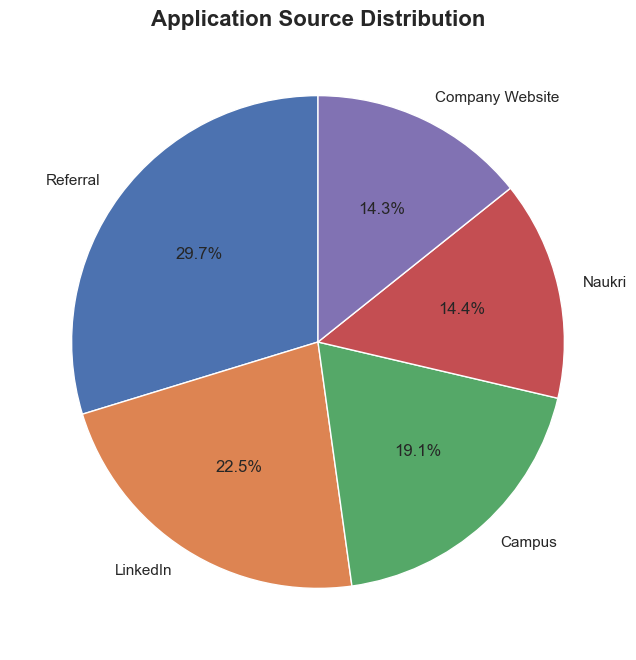

In [38]:
# =====================================================
# CHART 16 — SOURCE DISTRIBUTION
# =====================================================

source_distribution = recruitment_df['source'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    source_distribution,
    labels=source_distribution.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    "Application Source Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.show()

### Key  Insight

A large proportion of total applications originated from only a few recruitment channels, increasing dependency on limited sourcing platforms.

Heavy reliance on specific channels creates sourcing concentration risk and may reduce candidate diversity.

Expanding sourcing diversification strategies could strengthen long-term recruitment pipeline stability and talent quality.

# Recruitment Analytics Business Conclusion

The recruitment analysis identified major funnel drop-offs, department-specific hiring delays, recruiter performance gaps, and sourcing channel inefficiencies.

These findings can help HR leadership optimize hiring workflows, improve recruiter effectiveness, reduce hiring timelines, and increase overall workforce acquisition efficiency.

In [39]:
# =====================================================
# SAVE CLEANED DATASETS
# =====================================================

from pathlib import Path

# Create processed folder if not exists
processed_path = Path('../data/processed')

processed_path.mkdir(
    parents=True,
    exist_ok=True
)

# =====================================================
# ATTRITION CLEANING
# =====================================================

attrition_cleaned = attrition_df.copy()

# Drop useless columns
attrition_cleaned.drop(
    columns=[
        'employeecount',
        'over18',
        'standardhours'
    ],
    inplace=True
)

# Create target column
attrition_cleaned['attrition_binary'] = (
    attrition_cleaned['attrition']
    .map({'Yes':1, 'No':0})
)

# =====================================================
# RECRUITMENT CLEANING
# =====================================================

recruitment_cleaned = recruitment_df.copy()

# Convert date columns
date_columns = [
    'application_date',
    'screening_date',
    'interview_date',
    'offer_date',
    'joining_date'
]

for col in date_columns:

    recruitment_cleaned[col] = pd.to_datetime(
        recruitment_cleaned[col]
    )

# =====================================================
# SAVE FILES
# =====================================================

attrition_cleaned.to_csv(

    processed_path / 'attrition_cleaned.csv',

    index=False

)

recruitment_cleaned.to_csv(

    processed_path / 'recruitment_cleaned.csv',

    index=False

)

# =====================================================
# VALIDATION OUTPUT
# =====================================================

print("="*60)

print(" CLEANED DATASETS SAVED SUCCESSFULLY")

print("="*60)

print("\nAttrition Cleaned Shape:")

print(attrition_cleaned.shape)

print("\nRecruitment Cleaned Shape:")

print(recruitment_cleaned.shape)

print("\nSaved Files:")

print(
    processed_path / 'attrition_cleaned.csv'
)

print(
    processed_path / 'recruitment_cleaned.csv'
)

print("\nData preprocessing completed successfully")

Task was destroyed but it is pending!
task: <Task pending name='Task-218' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/anaconda3/envs/hranalytics/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-219' coro=<Kernel.shell_main() running at /opt/anaconda3/envs/hranalytics/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/anaconda3/envs/hranalytics/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
Exception ignored in: <coroutine object Kernel.shell_main at 0x11f0f0640>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Exception ignored in: <coroutine object Kernel.shell_main at 0x11f0f0640>
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
KeyError: '__import__'
Task was destroyed but it is pending!
task: <Task pending name='Task-219' coro=<Kernel.shell_ma

 CLEANED DATASETS SAVED SUCCESSFULLY

Attrition Cleaned Shape:
(1470, 33)

Recruitment Cleaned Shape:
(1500, 25)

Saved Files:
../data/processed/attrition_cleaned.csv
../data/processed/recruitment_cleaned.csv

Data preprocessing completed successfully
